# 08. Keyword spotting y detección de temas críticos

Este notebook parte de las transcripciones automáticas generadas en la fase anterior.

El objetivo es detectar palabras clave y expresiones relevantes en las llamadas, agrupándolas en temas críticos de negocio. Este análisis permite identificar llamadas potencialmente problemáticas, como incidencias técnicas, reclamaciones, problemas de facturación, bajas, fraude o insatisfacción elevada.

El análisis se realiza sin utilizar las transcripciones de referencia proporcionadas originalmente. Solo se emplean las transcripciones generadas automáticamente por el pipeline.

La salida principal será una tabla enriquecida a nivel de segmento y otra agregada a nivel de llamada.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
# =========================
# RUTAS PRINCIPALES
# =========================

PROJECT_DIR = Path("/home/jupyter/TFM_ProcesadoDeAudios")

TRANSCRIPTION_DIR = PROJECT_DIR / "data" / "transcription_outputs"
PER_AUDIO_DIR = TRANSCRIPTION_DIR / "per_audio"
TRANSCRIBED_SEGMENTS_CSV = TRANSCRIPTION_DIR / "all_segments_transcribed.csv"

KEYWORD_DIR = PROJECT_DIR / "data" / "keyword_outputs"
KEYWORD_DIR.mkdir(parents=True, exist_ok=True)

SEGMENTS_WITH_KEYWORDS_CSV = KEYWORD_DIR / "segments_with_keywords.csv"
CALL_LEVEL_KEYWORDS_CSV = KEYWORD_DIR / "call_level_keywords.csv"
TOP_CRITICAL_CALLS_CSV = KEYWORD_DIR / "top_critical_calls_keywords.csv"

print("TRANSCRIPTION_DIR:", TRANSCRIPTION_DIR)
print("PER_AUDIO_DIR:", PER_AUDIO_DIR)
print("KEYWORD_DIR:", KEYWORD_DIR)

TRANSCRIPTION_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/transcription_outputs
PER_AUDIO_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/transcription_outputs/per_audio
KEYWORD_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/keyword_outputs


**Consolidar transcripciones disponibles**

In [3]:
# =========================
# CONSOLIDAR TRANSCRIPCIONES DISPONIBLES
# =========================

transcribed_files = sorted(PER_AUDIO_DIR.glob("*_transcribed_segments.csv"))

print("Archivos transcritos disponibles:", len(transcribed_files))

if len(transcribed_files) == 0:
    raise FileNotFoundError(
        "No se han encontrado transcripciones en per_audio. "
        "Espera a que el notebook 06 genere al menos algunos CSV."
    )

dfs = []

for f in transcribed_files:
    df_tmp = pd.read_csv(f)
    df_tmp["transcription_csv"] = f.name
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)

df = df.sort_values(["audio_file", "start", "end"]).reset_index(drop=True)

df["text"] = df["text"].fillna("").astype(str).str.strip()
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].apply(lambda x: len(x.split()) if x else 0)

df.to_csv(TRANSCRIBED_SEGMENTS_CSV, index=False)

print("Dimensiones:", df.shape)
print("Audios únicos:", df["audio_file"].nunique())
print("Segmentos totales:", len(df))
print("Segmentos con texto:", int((df["n_chars"] > 0).sum()))
print("Segmentos vacíos:", int((df["n_chars"] == 0).sum()))

display(df.head())

Archivos transcritos disponibles: 1181
Dimensiones: (40352, 58)
Audios únicos: 1181
Segmentos totales: 40352
Segmentos con texto: 38872
Segmentos vacíos: 1480


,segment_id_raw,audio_file,audio_stem,start,end,duration,speaker,rms_dbfs,overlap_duration_sec,overlap_ratio,...,full_audio_n_words,assigned_words,word_assignment_coverage,audio_peak,audio_rms_dbfs,asr_retry_strategy,asr_retry_gain,transcription_csv,n_chars,n_words
0,1,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,0.030969,4.452219,4.421250,SPEAKER_01,-28.919975,0.000000,0.000000,...,494,483,0.977733,0.404785,-29.998554,none,1.0,9154117451310006851_transcribed_segments.csv,88,14
1,2,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,5.211594,6.342219,1.130625,SPEAKER_00,-33.883114,0.000000,0.000000,...,494,483,0.977733,0.404785,-29.998554,none,1.0,9154117451310006851_transcribed_segments.csv,13,2
2,3,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,6.426594,13.800969,7.374375,SPEAKER_01,-29.186810,0.000000,0.000000,...,494,483,0.977733,0.404785,-29.998554,none,1.0,9154117451310006851_transcribed_segments.csv,171,28
3,4,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,13.800969,14.965344,1.164375,SPEAKER_00,-36.389011,0.118125,0.101449,...,494,483,0.977733,0.404785,-29.998554,none,1.0,9154117451310006851_transcribed_segments.csv,3,1
4,5,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,15.285969,19.994094,4.708125,SPEAKER_01,-27.753717,0.000000,0.000000,...,494,483,0.977733,0.404785,-29.998554,none,1.0,9154117451310006851_transcribed_segments.csv,70,13


**Normalizar texto**: esto es importante para que dé igual si por ejemplo aparece facturación, FACTURACIÓN o facturacion, etc

In [4]:
# (Celda de consolidación duplicada eliminada durante la revisión.
#  Era idéntica a la celda anterior y reprocesaba las transcripciones
#  dos veces sin necesidad. El DataFrame 'df' ya está disponible.)

print('Consolidación ya realizada en la celda anterior.')

Consolidación ya realizada en la celda anterior.


**Diccionario de temas críticos**

In [5]:
# =========================
# FUNCIÓN DE NORMALIZACIÓN DE TEXTO
# =========================

import re
import unicodedata

def normalize_text(text):
    """
    Normaliza texto para comparar keywords:
    - pasa a minúsculas
    - elimina tildes
    - elimina signos raros
    - unifica espacios
    """
    if text is None:
        return ""
    
    text = str(text).lower().strip()
    
    # Quitar tildes
    text = unicodedata.normalize("NFKD", text)
    text = "".join(char for char in text if not unicodedata.combining(char))
    
    # Quitar puntuación/símbolos, manteniendo letras, números y espacios
    text = re.sub(r"[^\w\s]", " ", text)
    
    # Unificar espacios
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [6]:
# =========================
# DICCIONARIO AMPLIADO DE KEYWORDS POR TEMA CRÍTICO
# =========================

CRITICAL_KEYWORDS = {
    
    # 1. Riesgo de baja, cancelación o fuga del cliente
    "baja_cancelacion": [
        "baja",
        "dar de baja",
        "darme de baja",
        "darse de baja",
        "quiero la baja",
        "quiero darme de baja",
        "solicitar baja",
        "tramitar baja",
        "cancelar",
        "cancelacion",
        "anular",
        "rescindir",
        "rescision",
        "finalizar contrato",
        "romper contrato",
        "quitar el servicio",
        "quitar la linea",
        "quitar la fibra",
        "quitar internet",
        "no quiero seguir",
        "no quiero continuar",
        "me quiero ir",
        "me voy",
        "irme",
        "cambiar de compañia",
        "cambio de compañia",
        "otra compañia",
        "me cambio",
        "portabilidad",
        "hacer portabilidad",
        "solicitar portabilidad",
        "retencion",
        "departamento de bajas",
        "baja del servicio",
        "baja de la linea",
        "baja de fibra",
        "baja movil",
        "baja internet",
        "baixa",
        "donar de baixa",
        "vull donar-me de baixa",
        "cancel lar",
        "portabilitat"
    ],

    # 2. Facturación, cobros, pagos y disputas económicas
    "facturacion_cobros": [
        "factura",
        "facturas",
        "facturacion",
        "recibo",
        "recibos",
        "cobro",
        "cobros",
        "me han cobrado",
        "me habeis cobrado",
        "me cobraron",
        "cobrado de mas",
        "cobro indebido",
        "cargo",
        "cargos",
        "cargo duplicado",
        "doble cargo",
        "importe",
        "importe incorrecto",
        "cantidad incorrecta",
        "cuota",
        "tarifa",
        "precio",
        "subida de precio",
        "me ha subido",
        "me habeis subido",
        "mas caro",
        "muy caro",
        "descuento no aplicado",
        "promocion no aplicada",
        "oferta no aplicada",
        "no me han aplicado",
        "devolucion",
        "devolver dinero",
        "reembolso",
        "abono",
        "regularizacion",
        "pago",
        "pagos",
        "pagar",
        "pagado",
        "impago",
        "deuda",
        "deudas",
        "pendiente de pago",
        "domiciliacion",
        "domiciliado",
        "cuenta bancaria",
        "iban",
        "tarjeta",
        "datáfono",
        "datofono",
        "fraude en factura",
        "factura incorrecta",
        "factura mal",
        "no entiendo la factura",
        "explicar la factura",
        "detallar la factura",
        "factura més alta",
        "factura mes alta",
        "cobrament",
        "pagament",
        "rebut",
        "devolucio",
        "devolució"
    ],

    # 3. Incidencias técnicas de servicio
    "incidencia_tecnica": [
        "incidencia",
        "incidencias",
        "averia",
        "averias",
        "problema tecnico",
        "fallo tecnico",
        "fallo",
        "no funciona",
        "no me funciona",
        "no va",
        "no tengo servicio",
        "sin servicio",
        "sin internet",
        "no tengo internet",
        "internet no funciona",
        "sin conexion",
        "sin conexión",
        "no conecta",
        "no se conecta",
        "se corta",
        "se me corta",
        "cortes",
        "microcortes",
        "lento",
        "muy lento",
        "lentitud",
        "baja velocidad",
        "velocidad baja",
        "no carga",
        "no navega",
        "wifi",
        "wi fi",
        "wiffi",
        "router",
        "rúter",
        "reiniciar router",
        "fibra",
        "fibra optica",
        "instalacion",
        "instalador",
        "tecnico",
        "tecnica",
        "visita tecnica",
        "cita tecnica",
        "ont",
        "cable",
        "cableado",
        "roseta",
        "linea",
        "sin linea",
        "movil",
        "datos moviles",
        "sin datos",
        "no tengo datos",
        "cobertura",
        "sin cobertura",
        "mala cobertura",
        "llamadas cortadas",
        "no puedo llamar",
        "no puedo recibir llamadas",
        "sms",
        "sim",
        "tarjeta sim",
        "duplicado sim",
        "esim",
        "apn",
        "television",
        "tv",
        "decodificador",
        "desco",
        "canales",
        "no se ve",
        "pantalla negra",
        "avaria",
        "no funciona internet",
        "sense internet",
        "sense servei",
        "cobertura baixa",
        "router no funciona"
    ],

    # 4. Reclamaciones, quejas y escalado formal
    "reclamacion_queja": [
        "reclamacion",
        "reclamaciones",
        "reclamar",
        "quiero reclamar",
        "poner una reclamacion",
        "abrir reclamacion",
        "numero de reclamacion",
        "estado de reclamacion",
        "queja",
        "quejas",
        "quejarme",
        "me quiero quejar",
        "denuncia",
        "denunciar",
        "voy a denunciar",
        "consumo",
        "oficina de consumo",
        "facua",
        "ocu",
        "hoja de reclamaciones",
        "atencion al cliente",
        "mal servicio",
        "servicio pesimo",
        "servicio pésimo",
        "trato recibido",
        "no me solucionan",
        "nadie me soluciona",
        "no me ayudan",
        "nadie me ayuda",
        "he llamado varias veces",
        "llevo llamando",
        "no me hacen caso",
        "supervisor",
        "responsable",
        "pasame con un responsable",
        "pasame con un supervisor",
        "quiero hablar con un responsable",
        "escalar",
        "escalarlo",
        "reclamacio",
        "queixa",
        "atencio al client",
        "full de reclamacions"
    ],

    # 5. Insatisfacción fuerte, enfado o urgencia
    "insatisfaccion_urgencia": [
        "enfadado",
        "enfadada",
        "muy enfadado",
        "muy enfadada",
        "cabreado",
        "cabreada",
        "molesto",
        "molesta",
        "indignado",
        "indignada",
        "cansado",
        "cansada",
        "harto",
        "harta",
        "estoy harto",
        "estoy harta",
        "fatal",
        "horrible",
        "vergüenza",
        "verguenza",
        "es una vergüenza",
        "esto es una vergüenza",
        "no puede ser",
        "no hay derecho",
        "inaceptable",
        "esto es inaceptable",
        "esto es increible",
        "increible",
        "desesperado",
        "desesperada",
        "urgente",
        "urgencia",
        "lo necesito ya",
        "cuanto antes",
        "de inmediato",
        "no puedo mas",
        "no puedo más",
        "estoy desesperado",
        "estoy desesperada",
        "llevo esperando",
        "llevo dias",
        "llevo semanas",
        "llevo meses",
        "otra vez",
        "siempre igual",
        "ya esta bien",
        "ya está bien",
        "no me parece normal",
        "me parece fatal",
        "no tiene sentido",
        "malisimo",
        "malísimo",
        "pésimo",
        "pesimo",
        "nefasto",
        "molt enfadat",
        "molt enfadada",
        "estic fart",
        "estic farta",
        "urgent",
        "vergonya"
    ],

    # 6. Fraude, seguridad, identidad y accesos
    "fraude_seguridad": [
        "fraude",
        "fraudulento",
        "estafa",
        "estafado",
        "estafada",
        "suplantacion",
        "suplantacion de identidad",
        "identidad",
        "robo de identidad",
        "no soy yo",
        "no he sido yo",
        "yo no he contratado",
        "contrato falso",
        "firma falsa",
        "han contratado a mi nombre",
        "sin mi permiso",
        "sin autorizacion",
        "no he autorizado",
        "autorizacion",
        "titular",
        "cambio de titular",
        "titularidad",
        "dni",
        "documento",
        "contraseña",
        "password",
        "clave",
        "codigo de seguridad",
        "codigo sms",
        "sms de seguridad",
        "acceso",
        "no puedo acceder",
        "area cliente",
        "app",
        "mi cuenta",
        "cuenta bloqueada",
        "bloqueado",
        "phishing",
        "correo sospechoso",
        "mensaje sospechoso",
        "seguridad",
        "frau",
        "estafa",
        "suplantacio",
        "identitat",
        "contrasenya",
        "acces"
    ],

    # 7. Retención comercial, ofertas, competencia y permanencia
    "retencion_comercial": [
        "oferta",
        "ofertas",
        "descuento",
        "descuentos",
        "promocion",
        "promociones",
        "me ofrecieron",
        "me ofrecen",
        "me prometieron",
        "prometido",
        "no cumplen",
        "no se ha aplicado",
        "precio final",
        "condiciones",
        "contrato",
        "permanencia",
        "penalizacion",
        "penalizar",
        "penalizacion por baja",
        "compromiso de permanencia",
        "competencia",
        "otra compañia",
        "otra operadora",
        "me sale mas barato",
        "mas barato",
        "más barato",
        "mejor oferta",
        "contraoferta",
        "renovar",
        "renovacion",
        "fidelizacion",
        "cliente antiguo",
        "nuevo cliente",
        "promocio",
        "descompte",
        "permanencia",
        "penalitzacio"
    ],

    # 8. Esperas, derivaciones y experiencia operativa deficiente
    "espera_derivacion": [
        "espera",
        "esperando",
        "en espera",
        "llevo esperando",
        "mucho tiempo esperando",
        "me han dejado esperando",
        "transferir",
        "transferencia",
        "me transfieren",
        "me pasan",
        "me han pasado",
        "pasarme",
        "derivar",
        "derivacion",
        "departamento",
        "otro departamento",
        "me mandan a otro departamento",
        "me pasan de un lado a otro",
        "repetir",
        "tengo que repetir",
        "repetirlo todo",
        "ya lo he explicado",
        "ya he llamado",
        "he llamado varias veces",
        "varias llamadas",
        "nadie sabe",
        "no saben",
        "me cuelgan",
        "se ha cortado la llamada",
        "no me atienden",
        "llamada anterior",
        "esperant",
        "m han passat",
        "departament",
        "he trucat varies vegades"
    ],

    # 9. Instalaciones, citas técnicas y logística de técnicos
    "instalacion_citas": [
        "instalacion",
        "instalar",
        "instalador",
        "tecnico",
        "cita",
        "cita tecnica",
        "visita",
        "visita tecnica",
        "no ha venido",
        "no se ha presentado",
        "me han dejado plantado",
        "reprogramar",
        "cambiar cita",
        "anular cita",
        "confirmar cita",
        "franja horaria",
        "domicilio",
        "direccion",
        "mudanza",
        "traslado",
        "cambio de domicilio",
        "alta de fibra",
        "instal·lacio",
        "tecnic",
        "cita tecnica",
        "canvi de domicili"
    ],

    # 10. Alta, contratación y activación del servicio
    "alta_contratacion": [
        "alta",
        "dar de alta",
        "contratar",
        "contratacion",
        "nuevo contrato",
        "activacion",
        "activar",
        "no activado",
        "pendiente de activar",
        "pedido",
        "estado del pedido",
        "numero de pedido",
        "seguimiento del pedido",
        "router no llega",
        "sim no llega",
        "tarjeta no llega",
        "envio",
        "entrega",
        "mensajeria",
        "alta fibra",
        "alta movil",
        "alta internet",
        "contractacio",
        "activar servei",
        "alta servei"
    ],

    # 11. Datos personales, contrato y cambios administrativos
    "gestion_administrativa": [
        "datos personales",
        "cambiar datos",
        "modificar datos",
        "email",
        "correo",
        "telefono contacto",
        "direccion",
        "domicilio",
        "cambio de titular",
        "titular",
        "titularidad",
        "autorizado",
        "autorizada",
        "representante",
        "dni",
        "nie",
        "cif",
        "iban",
        "cuenta bancaria",
        "contrato",
        "copia del contrato",
        "condiciones del contrato",
        "documentacion",
        "firma",
        "signatura",
        "dades personals",
        "canvi de titular",
        "compte bancari"
    ],

    # 12. Casos de vulnerabilidad o impacto sensible
    "vulnerabilidad_impacto": [
        "persona mayor",
        "mi madre",
        "mi padre",
        "mis padres",
        "mayor",
        "anciano",
        "anciana",
        "dependiente",
        "discapacidad",
        "hospital",
        "medico",
        "médico",
        "teleasistencia",
        "trabajo desde casa",
        "teletrabajo",
        "necesito internet para trabajar",
        "necesito la linea",
        "no puedo trabajar",
        "negocio",
        "empresa",
        "tienda",
        "bar",
        "restaurante",
        "urgente por trabajo",
        "persona gran",
        "discapacitat",
        "hospital",
        "teletreball"
    ]
}

# Normalizamos y eliminamos duplicados dentro de cada tema
CRITICAL_KEYWORDS = {
    theme: sorted(list(set([normalize_text(kw) for kw in keywords if str(kw).strip() != ""])))
    for theme, keywords in CRITICAL_KEYWORDS.items()
}

print("Temas críticos definidos:", len(CRITICAL_KEYWORDS))

for theme, keywords in CRITICAL_KEYWORDS.items():
    print(f"{theme}: {len(keywords)} keywords")

Temas críticos definidos: 12
baja_cancelacion: 43 keywords
facturacion_cobros: 62 keywords
incidencia_tecnica: 78 keywords
reclamacion_queja: 42 keywords
insatisfaccion_urgencia: 56 keywords
fraude_seguridad: 46 keywords
retencion_comercial: 35 keywords
espera_derivacion: 35 keywords
instalacion_citas: 25 keywords
alta_contratacion: 25 keywords
gestion_administrativa: 28 keywords
vulnerabilidad_impacto: 26 keywords


**Funciones de detección**

In [7]:
# =========================
# FUNCIONES DE KEYWORD SPOTTING
# =========================

def keyword_to_pattern(keyword):
    """
    Convierte una keyword normalizada en patrón regex con límites de palabra.
    """
    keyword_norm = normalize_text(keyword)
    return r"(?<!\w)" + re.escape(keyword_norm) + r"(?!\w)"


def find_matches_by_theme(text_norm, keywords):
    """
    Devuelve las keywords encontradas en un texto para un tema concreto.
    """
    matches = []
    
    for kw in keywords:
        pattern = keyword_to_pattern(kw)
        if re.search(pattern, text_norm):
            matches.append(normalize_text(kw))
    
    return sorted(list(set(matches)))


def detect_critical_themes(text_norm):
    """
    Detecta todos los temas críticos presentes en un texto.
    """
    detected = {}
    
    for theme, keywords in CRITICAL_KEYWORDS.items():
        matches = find_matches_by_theme(text_norm, keywords)
        detected[theme] = matches
    
    return detected

**Aplicar keyword spotting por segmento**

In [8]:
# =========================
# DETECCIÓN DE KEYWORDS POR SEGMENTO
# =========================

import re

df_kw = df.copy()

# 1. Comprobamos que existe la columna de texto
if "text" not in df_kw.columns:
    raise KeyError(
        "No existe la columna 'text' en df_kw. "
        f"Columnas disponibles: {list(df_kw.columns)}"
    )

# 2. Creamos text_norm si no existe
if "text_norm" not in df_kw.columns:
    df_kw["text_norm"] = df_kw["text"].fillna("").apply(normalize_text)

print("Columna text_norm creada correctamente")
print("Segmentos a analizar:", len(df_kw))

# 3. Función para encontrar keywords dentro de cada segmento
def find_matches_by_theme(text, keywords):
    if pd.isna(text):
        return []
    
    text = str(text)
    matches = []
    
    for kw in keywords:
        kw = str(kw).strip()
        if kw == "":
            continue
        
        # Búsqueda simple sobre texto normalizado
        if kw in text:
            matches.append(kw)
    
    return sorted(list(set(matches)))

# 4. Aplicamos detección por cada tema crítico
for theme, keywords in CRITICAL_KEYWORDS.items():
    matched_col = f"kw_{theme}_matched"
    count_col = f"kw_{theme}_count"
    flag_col = f"kw_{theme}_flag"
    
    df_kw[matched_col] = df_kw["text_norm"].apply(
        lambda x: find_matches_by_theme(x, keywords)
    )
    
    df_kw[count_col] = df_kw[matched_col].apply(len)
    df_kw[flag_col] = df_kw[count_col] > 0

theme_flag_cols = [f"kw_{theme}_flag" for theme in CRITICAL_KEYWORDS.keys()]
theme_count_cols = [f"kw_{theme}_count" for theme in CRITICAL_KEYWORDS.keys()]

df_kw["n_critical_themes"] = df_kw[theme_flag_cols].sum(axis=1)
df_kw["total_keyword_matches"] = df_kw[theme_count_cols].sum(axis=1)
df_kw["has_critical_keyword"] = df_kw["total_keyword_matches"] > 0

def get_detected_themes(row):
    themes = []
    for theme in CRITICAL_KEYWORDS.keys():
        if row[f"kw_{theme}_flag"]:
            themes.append(theme)
    return themes

df_kw["critical_themes_detected"] = df_kw.apply(get_detected_themes, axis=1)

print("Segmentos totales:", len(df_kw))
print("Segmentos con keyword crítica:", int(df_kw["has_critical_keyword"].sum()))
print("Porcentaje:", round(df_kw["has_critical_keyword"].mean() * 100, 2), "%")

display(
    df_kw[
        ["audio_file", "start", "end", "speaker_final", "text", 
         "total_keyword_matches", "n_critical_themes", "critical_themes_detected"]
    ]
    .sort_values("total_keyword_matches", ascending=False)
    .head(20)
)

Columna text_norm creada correctamente
Segmentos a analizar: 40352
Segmentos totales: 40352
Segmentos con keyword crítica: 16878
Porcentaje: 41.83 %


,audio_file,start,end,speaker_final,text,total_keyword_matches,n_critical_themes,critical_themes_detected
17610,raw_bajas_9156561351300006851_clean.wav,181.656594,231.235344,SPEAKER_00,Cualquier comunicación a partir de ahora se va...,19,9,"[baja_cancelacion, facturacion_cobros, inciden..."
14068,raw_bajas_9156425565660006851_clean.wav,101.449719,149.138469,SPEAKER_00,"Ana. Vale, Ana. Te comento. Al realizar la con...",18,7,"[facturacion_cobros, incidencia_tecnica, fraud..."
12415,raw_bajas_9156329577480006851_clean.wav,93.315969,143.940969,SPEAKER_00,"Ahora mismo vosotros tenéis aquí dos líneas, ¿...",16,7,"[baja_cancelacion, facturacion_cobros, inciden..."
31755,raw_bajas_9157243717350006851_clean.wav,40.851594,80.254719,SPEAKER_01,"Claro, entonces te indico lo siguiente, digamo...",16,6,"[incidencia_tecnica, fraude_seguridad, retenci..."
25564,raw_bajas_9156994387760006851_clean.wav,26.035344,73.825344,SPEAKER_00,"dirigirme a ti, por favor? Mi nombre es Maribe...",16,9,"[baja_cancelacion, incidencia_tecnica, reclama..."
16455,raw_bajas_9156517979530006851_clean.wav,117.582219,145.628469,SPEAKER_01,Nosotros que hemos abierto una reclamación el ...,15,6,"[facturacion_cobros, incidencia_tecnica, recla..."
14055,raw_bajas_9156425565660006851_clean.wav,24.094719,57.490344,SPEAKER_00,"Ah, vale. En este caso se puede hacer un trasl...",14,3,"[incidencia_tecnica, instalacion_citas, gestio..."
19934,raw_bajas_9156682844120016851_clean.wav,59.650344,94.750344,SPEAKER_00,Excelente. Aquí lo tengo registrado en sistema...,14,4,"[baja_cancelacion, incidencia_tecnica, instala..."
21471,raw_bajas_9156770852160006851_clean.wav,168.645969,193.739094,SPEAKER_01,"¿Vale? Bueno, eso es elante. Este resumo, te c...",13,3,"[incidencia_tecnica, instalacion_citas, gestio..."
10054,raw_bajas_9156190911370006851_clean.wav,114.426594,140.430969,SPEAKER_00,"Como sería dentro de la misma provincia, se te...",13,6,"[baja_cancelacion, facturacion_cobros, inciden..."


**Guardar segmentos con keyworkds**

In [9]:
# =========================
# GUARDAR RESULTADO POR SEGMENTO
# =========================

df_kw.to_csv(SEGMENTS_WITH_KEYWORDS_CSV, index=False)

print("Archivo guardado en:")
print(SEGMENTS_WITH_KEYWORDS_CSV)

print("Dimensiones:", df_kw.shape)

Archivo guardado en:
/home/jupyter/TFM_ProcesadoDeAudios/data/keyword_outputs/segments_with_keywords.csv
Dimensiones: (40352, 99)


**Distribución de temas críticos**

In [10]:
# =========================
# DISTRIBUCIÓN DE TEMAS CRÍTICOS
# =========================

theme_summary_rows = []

for theme in CRITICAL_KEYWORDS.keys():
    flag_col = f"kw_{theme}_flag"
    count_col = f"kw_{theme}_count"
    
    theme_summary_rows.append({
        "theme": theme,
        "n_segments": int(df_kw[flag_col].sum()),
        "pct_segments": round(df_kw[flag_col].mean() * 100, 2),
        "total_keyword_matches": int(df_kw[count_col].sum())
    })

df_theme_summary = pd.DataFrame(theme_summary_rows)
df_theme_summary = df_theme_summary.sort_values("n_segments", ascending=False)

display(df_theme_summary)

,theme,n_segments,pct_segments,total_keyword_matches
2,incidencia_tecnica,8004,19.84,10912
0,baja_cancelacion,4067,10.08,5342
10,gestion_administrativa,3922,9.72,4814
5,fraude_seguridad,2365,5.86,3002
6,retencion_comercial,2198,5.45,2695
1,facturacion_cobros,2013,4.99,2674
8,instalacion_citas,2011,4.98,3252
7,espera_derivacion,1729,4.28,2672
11,vulnerabilidad_impacto,1484,3.68,1555
3,reclamacion_queja,964,2.39,1035


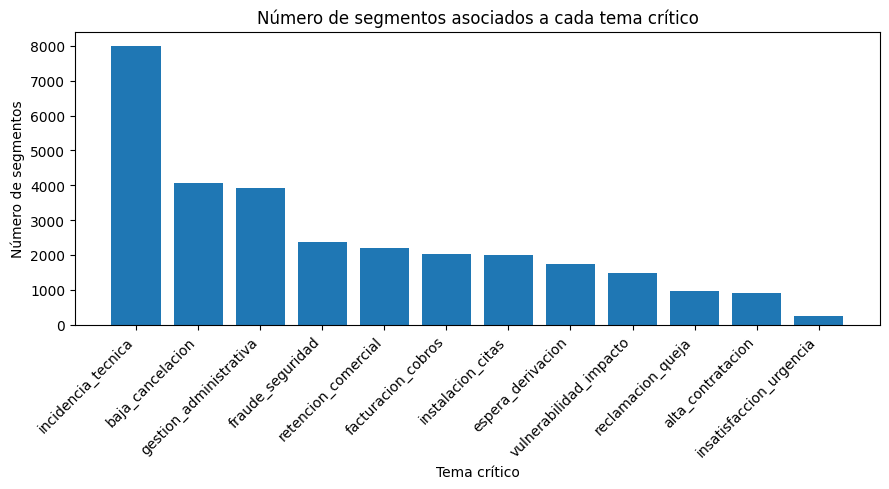

In [11]:
plt.figure(figsize=(9, 5))
plt.bar(df_theme_summary["theme"], df_theme_summary["n_segments"])
plt.title("Número de segmentos asociados a cada tema crítico")
plt.xlabel("Tema crítico")
plt.ylabel("Número de segmentos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Agregación por llamada**

In [12]:
# =========================
# AGREGACIÓN DE KEYWORDS POR LLAMADA
# =========================

base_call_agg = (
    df_kw
    .groupby("audio_file")
    .agg(
        n_segments=("text", "count"),
        n_segments_with_text=("n_chars", lambda x: (x > 0).sum()),
        n_segments_with_keywords=("has_critical_keyword", "sum"),
        total_keyword_matches=("total_keyword_matches", "sum"),
        n_theme_hits=("n_critical_themes", "sum"),
        total_duration=("duration", "sum"),
        total_words=("n_words", "sum")
    )
    .reset_index()
)

base_call_agg["pct_segments_with_keywords"] = (
    base_call_agg["n_segments_with_keywords"] / base_call_agg["n_segments"]
).round(4)

for theme in CRITICAL_KEYWORDS.keys():
    flag_col = f"kw_{theme}_flag"
    count_col = f"kw_{theme}_count"
    
    theme_call = (
        df_kw
        .groupby("audio_file")
        .agg(
            **{
                f"{theme}_segments": (flag_col, "sum"),
                f"{theme}_matches": (count_col, "sum")
            }
        )
        .reset_index()
    )
    
    base_call_agg = base_call_agg.merge(theme_call, on="audio_file", how="left")

# Número de temas distintos detectados por llamada
def call_detected_themes(audio_file):
    sub = df_kw[df_kw["audio_file"] == audio_file]
    themes = []
    for theme in CRITICAL_KEYWORDS.keys():
        if sub[f"kw_{theme}_flag"].any():
            themes.append(theme)
    return themes

base_call_agg["critical_themes_detected"] = base_call_agg["audio_file"].apply(call_detected_themes)
base_call_agg["n_distinct_critical_themes"] = base_call_agg["critical_themes_detected"].apply(len)

# Score simple de criticidad basado en keywords
base_call_agg["keyword_criticality_score"] = (
    base_call_agg["pct_segments_with_keywords"] * 3
    + np.log1p(base_call_agg["total_keyword_matches"])
    + base_call_agg["n_distinct_critical_themes"] * 0.5
)

base_call_agg["keyword_criticality_percentile"] = (
    base_call_agg["keyword_criticality_score"].rank(pct=True)
).round(4)

call_level_keywords = base_call_agg.sort_values(
    "keyword_criticality_score", ascending=False
).reset_index(drop=True)

call_level_keywords.to_csv(CALL_LEVEL_KEYWORDS_CSV, index=False)

print("Archivo guardado en:")
print(CALL_LEVEL_KEYWORDS_CSV)

display(call_level_keywords.head(20))

Archivo guardado en:
/home/jupyter/TFM_ProcesadoDeAudios/data/keyword_outputs/call_level_keywords.csv


,audio_file,n_segments,n_segments_with_text,n_segments_with_keywords,total_keyword_matches,n_theme_hits,total_duration,total_words,pct_segments_with_keywords,baja_cancelacion_segments,...,alta_contratacion_segments,alta_contratacion_matches,gestion_administrativa_segments,gestion_administrativa_matches,vulnerabilidad_impacto_segments,vulnerabilidad_impacto_matches,critical_themes_detected,n_distinct_critical_themes,keyword_criticality_score,keyword_criticality_percentile
0,raw_bajas_9156915870950006851_clean.wav,42,41,23,67,52,230.377500,698,0.5476,11,...,3,4,9,13,3,3,"[baja_cancelacion, facturacion_cobros, inciden...",12,11.862308,1.0000
1,raw_bajas_9157425562410006851_clean.wav,42,42,24,60,44,181.591875,569,0.5714,12,...,2,2,5,8,5,5,"[baja_cancelacion, facturacion_cobros, inciden...",12,11.825074,0.9992
2,raw_bajas_9155999629910006851_clean.wav,28,28,22,82,57,197.336250,618,0.7857,2,...,0,0,13,20,8,8,"[baja_cancelacion, facturacion_cobros, inciden...",10,11.775941,0.9983
3,raw_bajas_9156260293450006851_clean.wav,48,47,30,75,62,194.670000,606,0.6250,6,...,5,5,15,16,2,2,"[baja_cancelacion, facturacion_cobros, inciden...",11,11.705733,0.9975
4,raw_bajas_9156676921930016851_clean.wav,34,34,19,49,36,129.566250,544,0.5588,5,...,3,3,3,4,1,1,"[baja_cancelacion, facturacion_cobros, inciden...",12,11.588423,0.9966
5,raw_bajas_9157356527550016851_clean.wav,57,57,28,58,47,211.038750,672,0.4912,10,...,1,1,3,3,3,3,"[baja_cancelacion, facturacion_cobros, inciden...",12,11.551137,0.9958
6,raw_bajas_9156252819910006851_clean.wav,37,37,24,58,46,136.670625,483,0.6486,6,...,2,2,6,7,1,1,"[baja_cancelacion, incidencia_tecnica, reclama...",11,11.523337,0.9949
7,raw_bajas_9156336188520056851_clean.wav,38,37,25,56,49,180.714375,655,0.6579,12,...,2,2,5,5,6,6,"[baja_cancelacion, facturacion_cobros, inciden...",11,11.516751,0.9941
8,raw_bajas_9156674191330016851_clean.wav,42,42,24,71,54,188.595000,633,0.5714,10,...,2,3,9,11,1,1,"[baja_cancelacion, facturacion_cobros, inciden...",11,11.490866,0.9932
9,raw_bajas_9156683613980006851_clean.wav,56,55,26,56,42,215.021250,688,0.4643,10,...,2,2,5,8,2,2,"[baja_cancelacion, facturacion_cobros, inciden...",12,11.435951,0.9924


**Top llamadas críticas por keywords**

In [13]:
# =========================
# TOP LLAMADAS CRÍTICAS
# =========================

top_critical_calls = call_level_keywords.head(30).copy()

top_critical_calls.to_csv(TOP_CRITICAL_CALLS_CSV, index=False)

display(
    top_critical_calls[
        [
            "audio_file",
            "n_segments",
            "n_segments_with_keywords",
            "pct_segments_with_keywords",
            "total_keyword_matches",
            "n_distinct_critical_themes",
            "critical_themes_detected",
            "keyword_criticality_score",
            "keyword_criticality_percentile"
        ]
    ]
)

,audio_file,n_segments,n_segments_with_keywords,pct_segments_with_keywords,total_keyword_matches,n_distinct_critical_themes,critical_themes_detected,keyword_criticality_score,keyword_criticality_percentile
0,raw_bajas_9156915870950006851_clean.wav,42,23,0.5476,67,12,"[baja_cancelacion, facturacion_cobros, inciden...",11.862308,1.0000
1,raw_bajas_9157425562410006851_clean.wav,42,24,0.5714,60,12,"[baja_cancelacion, facturacion_cobros, inciden...",11.825074,0.9992
2,raw_bajas_9155999629910006851_clean.wav,28,22,0.7857,82,10,"[baja_cancelacion, facturacion_cobros, inciden...",11.775941,0.9983
3,raw_bajas_9156260293450006851_clean.wav,48,30,0.6250,75,11,"[baja_cancelacion, facturacion_cobros, inciden...",11.705733,0.9975
4,raw_bajas_9156676921930016851_clean.wav,34,19,0.5588,49,12,"[baja_cancelacion, facturacion_cobros, inciden...",11.588423,0.9966
5,raw_bajas_9157356527550016851_clean.wav,57,28,0.4912,58,12,"[baja_cancelacion, facturacion_cobros, inciden...",11.551137,0.9958
6,raw_bajas_9156252819910006851_clean.wav,37,24,0.6486,58,11,"[baja_cancelacion, incidencia_tecnica, reclama...",11.523337,0.9949
7,raw_bajas_9156336188520056851_clean.wav,38,25,0.6579,56,11,"[baja_cancelacion, facturacion_cobros, inciden...",11.516751,0.9941
8,raw_bajas_9156674191330016851_clean.wav,42,24,0.5714,71,11,"[baja_cancelacion, facturacion_cobros, inciden...",11.490866,0.9932
9,raw_bajas_9156683613980006851_clean.wav,56,26,0.4643,56,12,"[baja_cancelacion, facturacion_cobros, inciden...",11.435951,0.9924


**Revisión cualitativa de una llamada crítica**: para ver si el ranking tiene sentido

In [14]:
# =========================
# REVISIÓN CUALITATIVA DE LLAMADA CRÍTICA
# =========================

sample_audio = top_critical_calls.iloc[0]["audio_file"]

print("Llamada seleccionada:", sample_audio)

cols_review = [
    "start",
    "end",
    "speaker_final",
    "text",
    "total_keyword_matches",
    "n_critical_themes",
    "critical_themes_detected"
]

display(
    df_kw[df_kw["audio_file"] == sample_audio]
    .sort_values(["start", "end"])[cols_review]
)

Llamada seleccionada: raw_bajas_9156915870950006851_clean.wav


,start,end,speaker_final,text,total_keyword_matches,n_critical_themes,critical_themes_detected
23651,1.330344,10.341594,SPEAKER_00,Muy buenos días. Hola. Te llamo del departamen...,4,2,"[baja_cancelacion, espera_derivacion]"
23652,10.341594,11.084094,SPEAKER_01,Correcto.,0,0,[]
23653,12.332844,24.381594,SPEAKER_00,"Vale. Antonio, hemos recibido en este caso un ...",4,4,"[baja_cancelacion, incidencia_tecnica, fraude_..."
23654,25.410969,28.752219,SPEAKER_01,"eso no, no tenía. Sí, sí. Ah, sí, sí pero no t...",0,0,[]
23655,29.410344,42.927219,SPEAKER_00,"Ah, vale. Listo. En este caso pues directament...",5,4,"[incidencia_tecnica, fraude_seguridad, retenci..."
23656,43.652844,44.648469,SPEAKER_01,Evidentemente no.,0,0,[]
23657,46.335969,49.474719,SPEAKER_01,Solamente quiero dar de baja el teléfono. O se...,2,1,[baja_cancelacion]
23658,50.284719,54.233469,SPEAKER_01,Es una señora mayor con 96 años que viene a vi...,1,1,[vulnerabilidad_impacto]
23659,54.891594,61.945344,SPEAKER_00,"Vale, comprendo. En este caso, te pregunto, do...",1,1,[gestion_administrativa]
23660,66.585969,73.470969,SPEAKER_01,"complicado es esto, que si yo solamente da de ...",2,2,"[baja_cancelacion, alta_contratacion]"


**Integración opcional con sentimientos**

In [15]:
# =========================
# INTEGRACIÓN OPCIONAL CON SENTIMIENTOS
# =========================

SENTIMENT_DIR = PROJECT_DIR / "data" / "sentiment_outputs"
CALL_SENTIMENT_CSV = SENTIMENT_DIR / "call_level_sentiment.csv"

COMBINED_OUTPUT_CSV = KEYWORD_DIR / "call_level_keywords_sentiment_combined.csv"

if CALL_SENTIMENT_CSV.exists():
    call_sentiment = pd.read_csv(CALL_SENTIMENT_CSV)
    
    df_combined = call_level_keywords.merge(
        call_sentiment,
        on="audio_file",
        how="left"
    )
    
    # Componente de negatividad.
    # Si avg_sentiment va de -1 a 1, cuanto más negativo, mayor riesgo.
    df_combined["negative_sentiment_component"] = (
        -df_combined["avg_sentiment"].fillna(0)
    ).clip(lower=0)
    
    df_combined["combined_criticality_score"] = (
        df_combined["keyword_criticality_percentile"] * 0.6
        + df_combined["negative_sentiment_component"] * 0.4
    )
    
    df_combined = df_combined.sort_values(
        "combined_criticality_score", ascending=False
    ).reset_index(drop=True)
    
    df_combined.to_csv(COMBINED_OUTPUT_CSV, index=False)
    
    print("Archivo combinado guardado en:")
    print(COMBINED_OUTPUT_CSV)
    
    display(df_combined.head(20))
else:
    print("Todavía no existe call_level_sentiment.csv.")
    print("Cuando ejecutes el notebook 07, vuelve a ejecutar esta celda.")

Todavía no existe call_level_sentiment.csv.
Cuando ejecutes el notebook 07, vuelve a ejecutar esta celda.


**Resumen final**

In [16]:
# =========================
# RESUMEN FINAL
# =========================

final_keyword_summary = {
    "n_audios_analyzed": df_kw["audio_file"].nunique(),
    "n_segments_analyzed": len(df_kw),
    "n_segments_with_text": int((df_kw["n_chars"] > 0).sum()),
    "n_segments_with_keywords": int(df_kw["has_critical_keyword"].sum()),
    "pct_segments_with_keywords": round(df_kw["has_critical_keyword"].mean() * 100, 2),
    "n_calls_with_keywords": int((call_level_keywords["n_segments_with_keywords"] > 0).sum()),
    "pct_calls_with_keywords": round((call_level_keywords["n_segments_with_keywords"] > 0).mean() * 100, 2),
    "most_frequent_theme": df_theme_summary.iloc[0]["theme"] if len(df_theme_summary) > 0 else None
}

final_keyword_summary

{'n_audios_analyzed': 1181,
 'n_segments_analyzed': 40352,
 'n_segments_with_text': 38872,
 'n_segments_with_keywords': 16878,
 'pct_segments_with_keywords': np.float64(41.83),
 'n_calls_with_keywords': 1174,
 'pct_calls_with_keywords': np.float64(99.41),
 'most_frequent_theme': 'incidencia_tecnica'}